In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant

price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()

# Using Log prices
x = np.log(price_data['AAPL'])
y = np.log(price_data['MSFT'])

# Estimate beta value
X = add_constant(x)
model = OLS(y, X).fit()
beta = model.params[1]

# Construct spread
spread = y - beta * x
spread.head()

C:\Users\yogst\AppData\Local\Temp\ipykernel_34916\654514330.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


Date
2020-01-02    1.772237
2020-01-03    1.767132
2020-01-06    1.763682
2020-01-07    1.758105
2020-01-08    1.761780
dtype: float64

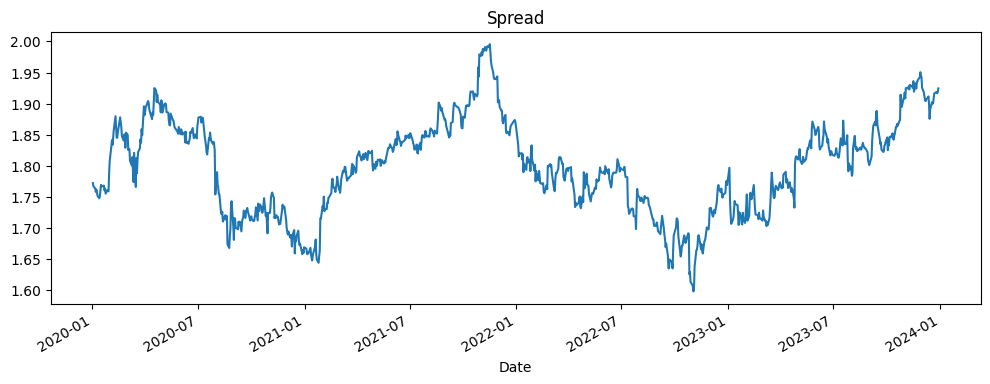

In [6]:
# Visualise the spread
spread.plot(figsize = (12,4))
plt.title("Spread")
plt.show()

In [24]:
# Calculate Mean-Reversion Speed (λ)
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag # give spread of each day

spread_lag = spread_lag.dropna() # remove first value as empty
spread_ret = spread_ret.loc[spread_lag.index] # re-index since we dropped the first value

X = add_constant(spread_lag)
model = OLS(spread_ret, X).fit()

lambda_ = model.params.iloc[1] # return the regression coeffiecient
print("Lambda: ", lambda_)

Lambda:  -0.013151895239546236


### Interpretation
Since our value of λ < 0, we have that the process mean-reverts, and also since it is a small negative, it suggests a slow decay (ie a slow speed of mean reversion)

In [15]:
# Compute the Half-Life
half_life = -np.log(2)/lambda_
print("Half Life (days): ", half_life)

Half Life (days):  52.70321637566968


### Interpretation Framework
Case A: λ > 0
- Not mean reverting, so the spread diverges.The strategy structurally invalid.

Case B: λ < 0 but small (e.g. −0.01)
- Half-life large (50–100+ days).
- Reversion too slow. Trading likely unprofitable after costs.

Case C: λ significantly negative (e.g. −0.1)
- Half-life small (~7 days).
- Strong mean reversion. Good trading candidate.
    
    

In [17]:
# Print a regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.018
Date:                Wed, 18 Feb 2026   Prob (F-statistic):             0.0143
Time:                        13:05:57   Log-Likelihood:                 2951.9
No. Observations:                1005   AIC:                            -5900.
Df Residuals:                    1003   BIC:                            -5890.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0238      0.010      2.467      0.0